### 🌸 **02. Classification avec KNN (K-Nearest Neighbors)**

Dans ce notebook, nous allons découvrir la **Classification**, une branche du Machine Learning où l'on cherche à prédire une catégorie (classe).

---

#### **Objectif**
Prédire l'espèce d'une fleur d'Iris (Setosa, Versicolor ou Virginica) en fonction de la taille de ses pétales et sépales.

#### 📌 **Plan du notebook**
- 📥 Chargement des librairies
- 📊 Présentation du dataset Iris
- 🔍 Visualisation des classes
- 🤖 Le principe de KNN (K-Plus Proches Voisins)
- 📏 Évaluation : Matrice de confusion, Précision, Rappel

### 📥 **Chargement des librairies**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("✅ Librairies prêtes !")

✅ Librairies prêtes !


### 📊 **Présentation du dataset Iris**

🔗 Lien Kaggle : [Iris Species](https://www.kaggle.com/datasets/uciml/iris)

C'est le dataset le plus célèbre en ML. Il contient 150 fleurs avec 4 mesures :
1. Longueur des sépales
2. Largeur des sépales
3. Longueur des pétales
4. Largeur des pétales

In [2]:
iris = load_iris()
data = iris.data
df = pd.DataFrame(data, columns=iris.feature_names)
df['species'] = iris.target

# On remplace les chiffres par les noms des espèces
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.sample(5)  # Affiche 5 lignes aléatoires du DataFrame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
129,7.2,3.0,5.8,1.6,2,virginica
59,5.2,2.7,3.9,1.4,1,versicolor
54,6.5,2.8,4.6,1.5,1,versicolor
76,6.8,2.8,4.8,1.4,1,versicolor
98,5.1,2.5,3.0,1.1,1,versicolor


### 🔍 **Visualisation des données**

Voyons comment les espèces se séparent selon la taille des pétales.

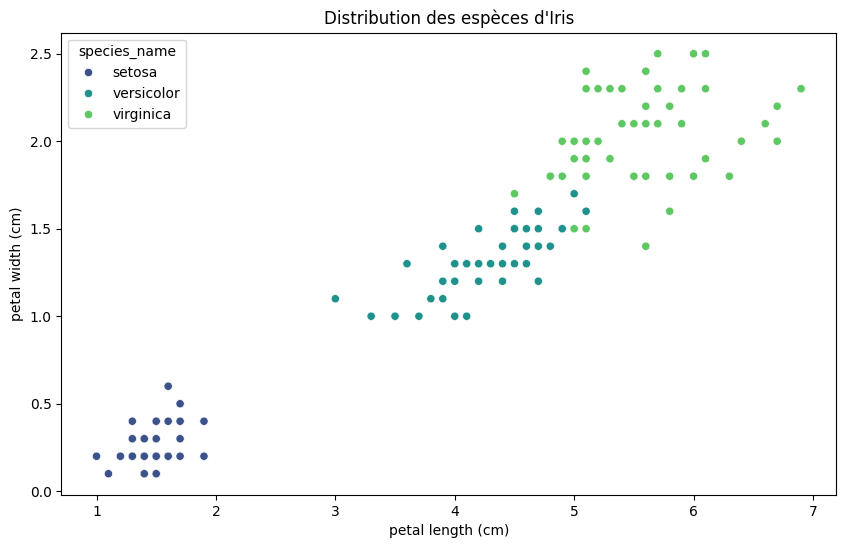

' \nLa règle d\'or :\nDans seaborn : x=\'nom_colonne\' = "Va chercher TOUTES les données dans cette colonne et utilise-les pour positionner les points sur l\'axe X"\npareil pour y=\'nom_colonne\' et hue=\'nom_colonne\'\n\nCe n\'est PAS un label, c\'est une instruction pour trouver les données.\n\n\nPar contre, dans matplotlib, on doit fournir les données directement :\nplt.scatter(x=df[\'petal length (cm)\'], y=df[\'petal width (cm)\'], c=df[\'species\'])\nplt.title("Distribution des espèces d\'Iris")\nplt.show()\n\n\n'

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, 
                x='petal length (cm)',
                y='petal width (cm)', 
                hue='species_name',  # hue pour colorer par espèce
                palette='viridis')  # palette pour choisir les couleurs
plt.title("Distribution des espèces d'Iris")
plt.show()

""" 
La règle d'or :
Dans seaborn : x='nom_colonne' = "Va chercher TOUTES les données dans cette colonne et utilise-les pour positionner les points sur l'axe X"
pareil pour y='nom_colonne' et hue='nom_colonne'

Ce n'est PAS un label, c'est une instruction pour trouver les données.


Par contre, dans matplotlib, on doit fournir les données directement :
plt.scatter(x=df['petal length (cm)'], y=df['petal width (cm)'], c=df['species'])  # c pour colorer par espèce
plt.title("Distribution des espèces d'Iris")
plt.xlabel("Longueur du pétale (cm)")
plt.ylabel("Largeur du pétale (cm)")
plt.show()


"""

### 🤖 **Le modèle KNN**

**KNN** fonctionne par analogie : pour classer un nouveau point, il regarde les **K** voisins les plus proches et lui attribue la classe majoritaire.

In [35]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# On choisit K=3 pour commencer, c'est un choix courant
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

print("🚀 Modèle KNN entraîné !")

🚀 Modèle KNN entraîné !


### 📊 **Évaluation du modèle**

La **Matrice de Confusion** permet de voir où le modèle se trompe.

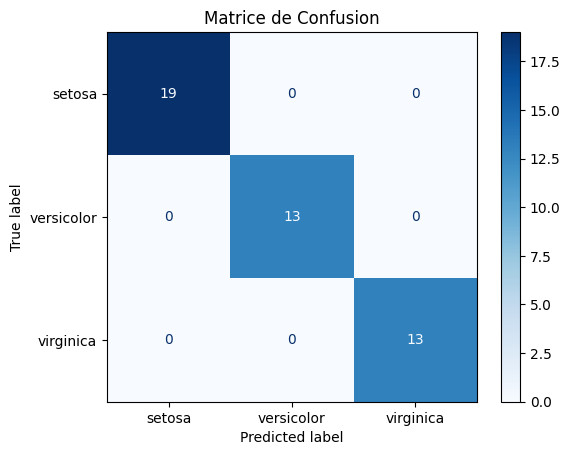


--- Rapport de Classification ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [37]:
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title("Matrice de Confusion")
plt.show()

print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

### 💡 **Interprétation**

- **Précision** : Parmi toutes les fleurs prédites comme 'Setosa', combien l'étaient vraiment ?
- **Rappel (Recall)** : Parmi toutes les 'Setosa' réelles, combien le modèle en a-t-il trouvées ?
- **F1-Score** : Moyenne entre précision et rappel.

1. Structure générale

- Lignes (axe vertical) = vraies classes (labels réels)
- Colonnes (axe horizontal) = classes prédites par le modèle
- Diagonale principale = prédictions correctes
- Hors diagonale = erreurs (confusions entre classes)

2. Verdict 

- **setosa** :
    - 19 correctement classées
    - 0 erreurs → jamais confondue avec les autres

- **versicolor** :
    - 13 correctement classées
    - 0 erreurs

- **virginica** :
    - 13 correctement classées
    - 0 erreurs


3. Conclusion globale

👉 Le modèle est parfait sur cet ensemble de test :

- **Aucune confusion**
- **100% de précision (accuracy = 1.0)**
- **Précision, rappel, F1-score = 1.0 pour toutes les classes**


4. Attention (point critique)

Même si le résultat est parfait, il faut vérifier :

- Taille du dataset (ici assez petit : 19 + 13 + 13 = 45)
- Risque de surapprentissage (overfitting)
- Séparation facile des classes (c’est typique du dataset Iris)

### Exemple de prédiction

In [43]:
# Prédictions sur de nouvelles données
# [5.1, 3.5, 1.4, 0.2] chaque valeur correspond à une caractéristique : longueur sépale, largeur sépale, longueur pétale, largeur pétale


new_samples = [[5.1, 3.5, 1.4, 0.2],  # Probablement setosa  
                [6.0, 2.9, 4.5, 1.5],  # Probablement versicolor
                [6.5, 3.0, 5.8, 2.2]]  # Probablement virginica  

new_predictions = knn.predict(new_samples)
print(new_predictions)  # Affiche les classes prédites (0, 1 ou 2)

for i, pred in enumerate(new_predictions):
    print(f"Échantillon {i+1} prédit comme : {iris.target_names[pred]}")


[0 1 2]
Échantillon 1 prédit comme : setosa
Échantillon 2 prédit comme : versicolor
Échantillon 3 prédit comme : virginica
